In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv(r"C:\MCA\DataScience\DataSets\smartphone_prices.csv")
df.head(10)

,brand,ram_gb,price
0,Samsung,4,15000
1,Apple,4,45000
2,OnePlus,6,30000
3,Samsung,6,18000
4,Apple,6,48000
5,OnePlus,8,32000
6,Samsung,8,20000
7,Apple,8,50000
8,OnePlus,12,35000
9,Samsung,12,21000


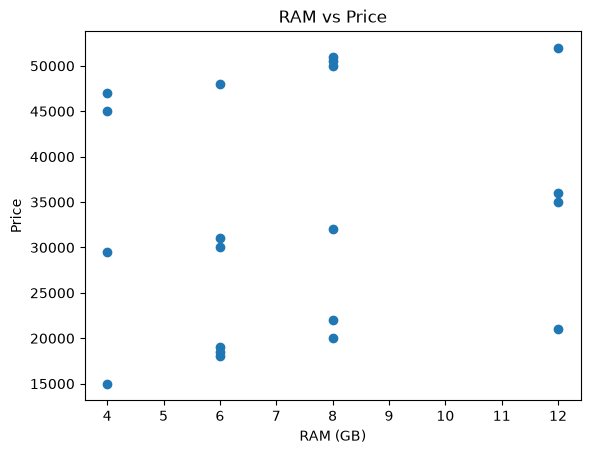

In [5]:
#Visualize the relationship between RAM and price, and between brand and price.
plt.scatter(df['ram_gb'], df['price'])
plt.title('RAM vs Price')
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.show()

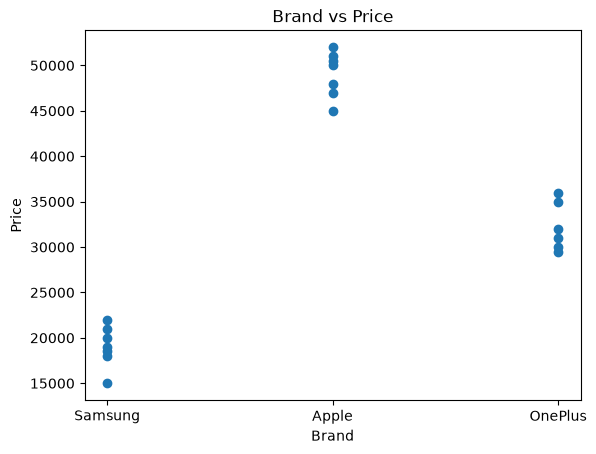

In [6]:
plt.scatter(df['brand'], df['price'])
plt.title('Brand vs Price')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.show()

In [ ]:




brand_dummies = pd.get_dummies(df['brand'], drop_first=True)

df = pd.concat([df.drop('brand', axis=1), brand_dummies], axis=1)

print(df.head())

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


In [9]:
df = pd.read_csv('DataSets/smartphone_prices.csv')
df

,brand,ram_gb,price
0,Samsung,4,15000
1,Apple,4,45000
2,OnePlus,6,30000
3,Samsung,6,18000
4,Apple,6,48000
5,OnePlus,8,32000
6,Samsung,8,20000
7,Apple,8,50000
8,OnePlus,12,35000
9,Samsung,12,21000


In [11]:
print('Unique Brands:', df['brand'].unique())

Unique Brands: <StringArray>
['Samsung', 'Apple', 'OnePlus']
Length: 3, dtype: str


In [13]:
df.describe()

,ram_gb,price
count,20.000000,20.000000
mean,7.400000,33525.000000
std,2.760625,13115.353598
min,4.000000,15000.000000
25%,6.000000,20750.000000
50%,7.000000,31500.000000
75%,8.000000,47250.000000
max,12.000000,52000.000000


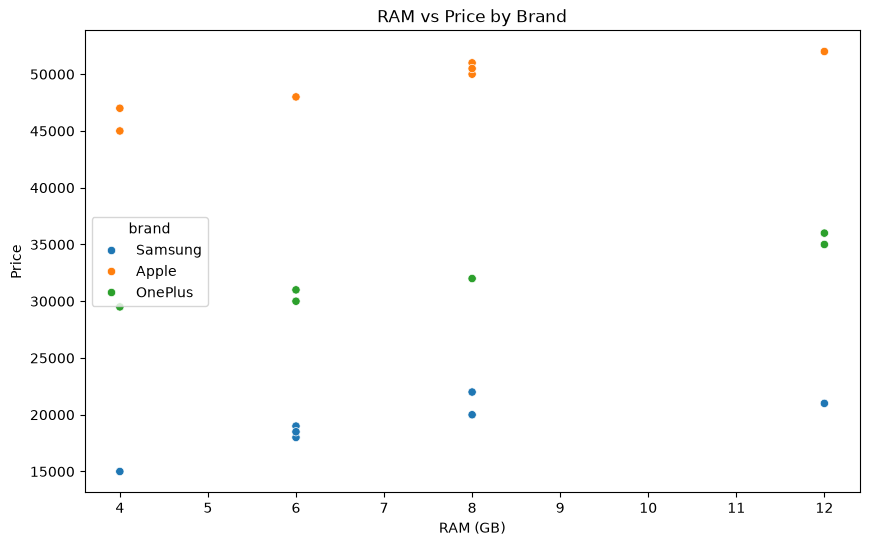

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='ram_gb', y='price', data=df, hue='brand')
plt.title('RAM vs Price by Brand')
plt.xlabel('RAM (GB)')
plt.ylabel('Price')
plt.show()

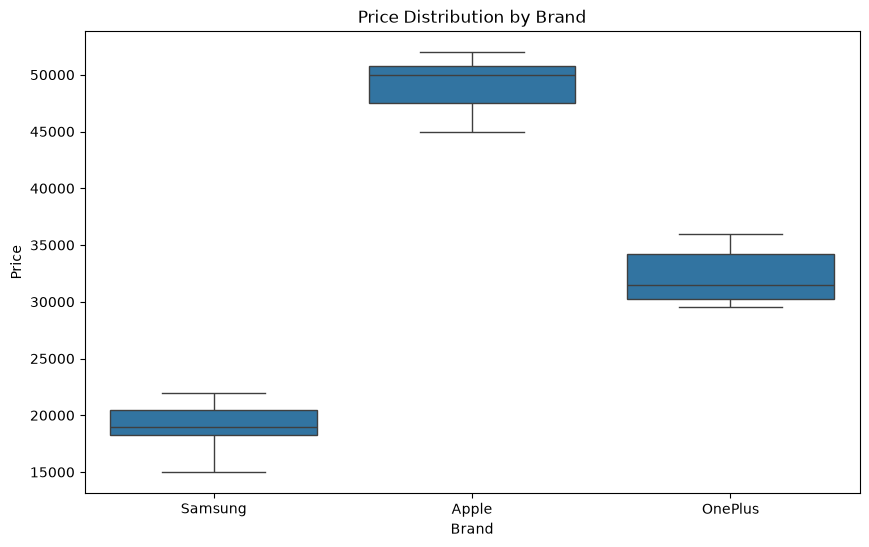

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(y='price', x='brand', data=df)
plt.title('Price Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Price')
plt.show()

In [18]:
df_dummies = pd.get_dummies(df, columns=['brand'], dtype=int)
df_dummies.head()

,ram_gb,price,brand_Apple,brand_OnePlus,brand_Samsung
0,4,15000,0,0,1
1,4,45000,1,0,0
2,6,30000,0,1,0
3,6,18000,0,0,1
4,6,48000,1,0,0


In [19]:
df_dummies = df_dummies.drop('brand_Apple', axis=1)
df_dummies.head()

,ram_gb,price,brand_OnePlus,brand_Samsung
0,4,15000,0,1
1,4,45000,0,0
2,6,30000,1,0
3,6,18000,0,1
4,6,48000,0,0


### modeling with dummy var

**Why X is capital => X is two dimentional and y is small because it is one dimentional**

In [20]:
X=df_dummies.drop('price', axis=1)
y=df_dummies['price']
model = LinearRegression()
model.fit(X, y)
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('R-squared:', model.score(X, y))


Coefficients: [   775.2016129  -17485.88709677 -30000.        ]
Intercept: 43534.27419354838
R-squared: 0.9941429785635915


***One Hot Encoading with Scikit-Learn***

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [23]:

X2=df[['brand', 'ram_gb']]
y2=df['price']
ct = ColumnTransformer([('brand_ohe', OneHotEncoder(drop = 'first'), ['brand'])], remainder = 'passthrough')
X2_encoded = ct.fit_transform(X2)

In [25]:
model2=LinearRegression()
model2.fit(X2_encoded, y2)
print('Coefficients:', model2.coef_)
print('Intercept:', model2.intercept_)
print('R-squared:', model2.score(X2_encoded, y2))

Coefficients: [-17485.88709677 -30000.            775.2016129 ]
Intercept: 43534.27419354842
R-squared: 0.9941429785635915


******Predict******

In [27]:
pred_new=model2.predict([[1, 0, 8]])  # Assuming brand is the second category and RAM is 8 GB
print('Predicted Price for Brand 2 with 8GB RAM:', pred_new[0])

Predicted Price for Brand 2 with 8GB RAM: 32249.999999999993


In [ ]:
pred_new=model2.predict([[1, 0, 32]])  
print( pred_new[0])

Predicted Price for Brand 2 with 32GB RAM: 50854.83870967727
